# Procesamiento de imágenes LASCO y diagrama altura-tiempo — Evento 1 (halo del 17/12/2024)

**Tesis:** Cálculo cinemático y estimación volumétrica de CMEs tipo halo con SunPy

**Qué hace este cuaderno (ejecutar de arriba hacia abajo con Shift + Enter):**
1. Lee las imágenes FITS de LASCO C2 y C3 (descargadas con `01_descargar_evento1.ipynb`).
2. Normaliza por exposición y calcula la **diferencia corrida** (imagen actual − imagen anterior).
3. Calcula para cada píxel su distancia al Sol (en R☉) y su **ángulo de posición (PA)** usando el encabezado FITS.
4. Toma un sector de PA fijo, construye el **perfil radial** de la imagen de diferencia y detecta el **borde delantero** de la CME como el escalón más marcado.
5. Guarda la tabla altura-tiempo (`ht_evento1.csv`), imágenes de control de calidad y el diagrama h-t.

**Validación con datos reales** (muestra 15:48–16:54 UT): las imágenes traen `CROTA` ≈ 173° (casi al revés, Norte abajo); el cuaderno usa la matriz de rotación del encabezado, así que el PA que calcula es el real (0 = Norte, 90 = Este, 180 = Sur).
El barrido de PA mostró el frente más avanzado en PA ≈ 180°, por eso `PA_CENTRO = 178` es una buena elección. Frente a las marcas manuales, las alturas automáticas quedan en promedio 0.28 R☉ más abajo (el automático marca el punto medio del escalón; a mano se marca el borde exterior) y la velocidad en C3 (16:18–16:54) coincide: 2125 km/s frente a 2135 km/s.

**Errores de la versión anterior, ya corregidos:** no se restaban imágenes (se buscaba el píxel más brillante de la imagen cruda, siempre la misma estructura fija); `max_row` era un índice y no píxeles; se usaban 122 px/R☉ para C2 y C3 (en realidad ~82 y ~17); el ángulo 175–181° se usaba como ángulo matemático y no como PA; y el centro del Sol se suponía en (512, 512) en vez de leerlo del encabezado.

## 1. Importaciones

In [1]:
%matplotlib inline
from pathlib import Path                    # manejo de rutas de archivos independiente del sistema operativo
import csv                                  # para escribir la tabla h-t en un archivo CSV
import numpy as np                          # cálculo numérico con arreglos
import matplotlib.pyplot as plt             # gráficos
import matplotlib.dates as mdates           # formato de horas en el eje x
import astropy.units as u                   # unidades físicas (arcsec, pix, s)
import sunpy.map                            # lectura de imágenes FITS como "mapas" de SunPy
from scipy.ndimage import uniform_filter1d  # suavizado de un perfil 1D (media móvil)

# ----------------------------------------------------------------------------

## 2. Parámetros ajustables

Todo lo que puedes cambiar está en esta celda. **`PA_CENTRO`**: conviene ajustarlo al MPA (*Measurement Position Angle*) que da el catálogo CDAW para este evento.
Si tus imágenes están en otra carpeta, cambia `CARPETA_DATOS` (en Windows, por defecto es `C:\Users\<tu usuario>\lasco_evento1`).

In [2]:
CARPETA_DATOS = Path.home() / "lasco_evento1"   # carpeta que contiene las subcarpetas c2/ y c3/ (la crea 01_descargar_evento1.py)
CARPETA_SALIDA = Path("resultados_evento1")     # aquí se guardan CSV, figuras y control de calidad
RSUN_KM = 695700.0                              # radio solar en km (valor nominal de la IAU)

PA_CENTRO = 178.0        # ángulo de posición central del sector (grados, desde el Norte hacia el Este; 180 = Sur)
PA_SEMIANCHO = 3.0       # semiancho del sector en grados (175 a 181 equivale a 178 ± 3)
#   RECOMENDACIÓN: ajustar PA_CENTRO al MPA (Measurement Position Angle) que da el catálogo CDAW para este evento.

DETECTORES = {           # parámetros propios de cada coronógrafo
    "C2": dict(subcarpeta="c2",
               r_min=2.5, r_max=6.2,   # rango radial útil en R_sun (C2 ve de ~2.2 a ~6.3 sobre los ejes; se evita el borde)
               dr=0.05,                # ancho de cada bin radial (R_sun)
               k_borde=4,              # nº de bins a cada lado del borde que se comparan (interior vs exterior)
               tol_retroceso=0.5),     # cuánto se permite "retroceder" el frente respecto a la medición anterior (R_sun)
    "C3": dict(subcarpeta="c3",
               r_min=4.0, r_max=29.0,  # C3 ve de ~3.7 a 30 R_sun
               dr=0.15,
               k_borde=4,
               tol_retroceso=1.0),
}
N_SUAVIZADO = 3          # nº de bins de la media móvil que suaviza el perfil (solo se usa para afinar la posición del borde)
UMBRAL_SNR = 10.0        # el escalón del borde debe superar 10 veces el ruido local (con datos reales el ruido puro llega a ~7.5; los frentes reales dan >= 14)
V_MAX_KMS = 4000.0      # velocidad máxima físicamente razonable de una CME (km/s); descarta saltos imposibles entre mediciones
FRACCION_EXTERIOR_MAX = 0.4  # afuera del frente la señal debe ser menor al 40 % de la señal de adentro (rechaza "bordes" falsos dentro del cuerpo de la CME)
NIVEL_BORDE = 0.5        # dónde se marca el borde dentro del escalón: 0.5 = punto medio; valores menores (0.2-0.3) lo desplazan hacia afuera, hacia el pie difuso del frente


# ----------------------------------------------------------------------------

print("Leyendo imágenes de:", CARPETA_DATOS)
print("Guardando resultados en:", CARPETA_SALIDA.resolve())

Leyendo imágenes de: C:\Users\Steve\lasco_evento1
Guardando resultados en: C:\Users\Steve\Aprendiendo Python\resultados_evento1


## 3. Funciones auxiliares

### 3.1 Leer las imágenes

Lee todos los `.fts` de una carpeta con SunPy y los ordena por hora.

In [3]:
def leer_secuencia(carpeta):
    """Lee todos los .fts de una carpeta y los devuelve ordenados por fecha."""
    mapas = []                                          # lista donde se guardarán los mapas de SunPy
    for ruta in sorted(carpeta.glob("*.fts")):          # recorre cada archivo .fts de la carpeta
        try:
            mapas.append(sunpy.map.Map(str(ruta)))      # SunPy lee el FITS y su encabezado
        except Exception as error:                      # si un archivo está dañado, se avisa y se continúa
            print(f"  aviso: no se pudo leer {ruta.name}: {error}")
    mapas.sort(key=lambda m: m.date.jd)                 # ordena por fecha (día juliano)
    return mapas

### 3.2 Geometría de la imagen

Para cada píxel calcula su distancia al Sol (en R☉) y su ángulo de posición (PA). Usa el **centro, la escala y el giro del encabezado FITS**, no valores fijos.

In [4]:
def geometria(mapa):
    """
    Devuelve dos matrices del tamaño de la imagen:
      radio -> distancia de cada píxel al centro del Sol, en radios solares
      pa    -> ángulo de posición (grados, del Norte hacia el Este)
    Se usa el encabezado FITS (centro, escala y rotación), no valores fijos.
    """
    ny, nx = mapa.data.shape                            # nº de filas y columnas de la imagen
    fila, col = np.indices((ny, nx))                    # índice de fila y de columna de cada píxel
    cx = mapa.reference_pixel.x.to_value(u.pix)         # columna del centro del Sol (según CRPIX del encabezado)
    cy = mapa.reference_pixel.y.to_value(u.pix)         # fila del centro del Sol
    dx = col - cx                                       # desplazamiento en píxeles respecto al centro (eje x)
    dy = fila - cy                                      # desplazamiento en píxeles respecto al centro (eje y)
    rot = mapa.rotation_matrix                          # matriz 2x2 de rotación (LASCO gira 180° según la época del año)
    esc_x = mapa.scale.axis1.to_value(u.arcsec / u.pix) # escala en arcsec por píxel (eje x)
    esc_y = mapa.scale.axis2.to_value(u.arcsec / u.pix) # escala en arcsec por píxel (eje y)
    tx = esc_x * (rot[0, 0] * dx + rot[0, 1] * dy)      # coordenada solar X en arcsec (+X = Oeste)
    ty = esc_y * (rot[1, 0] * dx + rot[1, 1] * dy)      # coordenada solar Y en arcsec (+Y = Norte)
    rsun_arcsec = mapa.rsun_obs.to_value(u.arcsec)      # radio solar aparente en arcsec
    radio = np.hypot(tx, ty) / rsun_arcsec              # distancia al centro en radios solares
    pa = np.degrees(np.arctan2(-tx, ty)) % 360.0        # PA: 0 = Norte, 90 = Este, 180 = Sur, 270 = Oeste
    return radio, pa

### 3.3 Sector angular

Marca los píxeles cuyo PA está dentro de `PA_CENTRO ± PA_SEMIANCHO` (maneja el cruce 360° → 0°).

In [5]:
def mascara_sector(pa, pa_centro, semiancho):
    """True en los píxeles cuyo PA está dentro de pa_centro ± semiancho (maneja el cruce 360°->0°)."""
    dif = (pa - pa_centro + 180.0) % 360.0 - 180.0      # diferencia angular con signo, en [-180, 180)
    return np.abs(dif) <= semiancho                     # dentro del sector si |diferencia| <= semiancho

### 3.4 Diferencia corrida

Resta la imagen anterior de la actual, ambas normalizadas por su tiempo de exposición. Los píxeles sin dato quedan como NaN.

In [6]:
def imagen_diferencia(actual, previa):
    """Diferencia corrida normalizada por exposición: (actual/t_exp) - (previa/t_exp)."""
    t_act = actual.exposure_time.to_value(u.s)          # tiempo de exposición de la imagen actual (s)
    t_pre = previa.exposure_time.to_value(u.s)          # tiempo de exposición de la imagen previa (s)
    a = actual.data.astype(float)                       # datos actuales como decimales (evita problemas de enteros)
    b = previa.data.astype(float)                       # datos previos como decimales
    dif = a / t_act - b / t_pre                         # resta de imágenes ya normalizadas por exposición
    dif[(a <= 0) | (b <= 0)] = np.nan                   # píxeles sin dato (bloques perdidos o fuera de campo) -> NaN
    return dif

### 3.5 Perfil radial

Promedia la imagen de diferencia en anillos (bins de radio) dentro del sector angular.

In [7]:
def perfil_radial(dif, radio, sector, r_min, r_max, dr):
    """Promedia la imagen de diferencia en bins de radio dentro del sector angular."""
    n_bins = int(np.ceil((r_max - r_min) / dr))                     # cantidad de bins radiales
    sel = sector & (radio >= r_min) & (radio < r_max) & np.isfinite(dif)  # píxeles válidos del sector y del rango radial
    idx = ((radio[sel] - r_min) / dr).astype(int)                   # bin al que pertenece cada píxel seleccionado
    suma = np.bincount(idx, weights=dif[sel], minlength=n_bins)     # suma de valores en cada bin
    cuenta = np.bincount(idx, minlength=n_bins)                     # cuántos píxeles cayeron en cada bin
    perfil = np.full(n_bins, np.nan)                                # perfil inicial: todo NaN
    perfil[cuenta > 0] = suma[cuenta > 0] / cuenta[cuenta > 0]      # promedio por bin (solo donde hay píxeles)
    centros = r_min + (np.arange(n_bins) + 0.5) * dr                # radio central de cada bin (R_sun)
    return centros, perfil

### 3.6 Detección del frente

Busca el borde delantero como el **escalón más grande** del perfil (señal positiva por dentro, poca señal por fuera). Exige SNR ≥ `UMBRAL_SNR`, que la señal exterior sea menor al 40 % de la interior y que la velocidad implícita no supere `V_MAX_KMS`. Si no hay una detección fiable devuelve `None` en lugar de inventar un valor.

In [8]:
def detectar_frente(centros, perfil, r_previo, dt_s, tol_retroceso, k):
    """
    Busca el borde delantero de la CME como el ESCALÓN más marcado del perfil radial:
    en la imagen de diferencia, dentro del frente hay señal positiva y justo afuera hay solo ruido.
    Devuelve (radio_frente, snr, motivo). Si no hay detección fiable, radio_frente = None.
    """
    n = len(perfil)                                     # número de bins radiales
    valido = np.isfinite(perfil)                        # bins que sí tienen datos
    if valido.sum() < 3 * k:                            # con muy pocos datos no se puede medir
        return None, 0.0, "sin datos"
    p = np.interp(np.arange(n), np.flatnonzero(valido), perfil[valido])  # rellena huecos con interpolación lineal
    sigma = 1.4826 * np.median(np.abs(np.diff(p))) / np.sqrt(2)          # ruido bin a bin (MAD de las diferencias, robusto)
    sigma = max(sigma, 1e-12)                           # evita dividir por cero si el perfil fuera perfectamente liso
    suma = np.concatenate(([0.0], np.cumsum(p)))        # sumas acumuladas para calcular medias de ventanas rápidamente
    i = np.arange(2 * k, n - k)                         # candidatos: dejan k bins fuera y 2k bins dentro (evita el borde interno del campo)
    media_int = (suma[i + 1] - suma[i + 1 - k]) / k     # media de los k bins INTERNOS (hacia el Sol) de cada candidato
    media_ext = (suma[i + 1 + k] - suma[i + 1]) / k     # media de los k bins EXTERNOS (alejándose del Sol)
    caida = media_int - media_ext                       # tamaño del escalón: interior brillante menos exterior
    snr = caida / (sigma * np.sqrt(2.0 / k))            # significancia del escalón frente al ruido de esas medias
    lim_inf = centros[0] if r_previo is None else r_previo - tol_retroceso  # el frente no debe retroceder demasiado
    lim_sup = np.inf if r_previo is None else r_previo + V_MAX_KMS * dt_s / RSUN_KM   # ni avanzar más de lo que permite V_MAX_KMS
    exterior_vacio = (media_int > 0) & (media_ext <= FRACCION_EXTERIOR_MAX * media_int)  # afuera del frente la señal debe ser mucho menor que adentro
    permitido = (centros[i] >= lim_inf) & (centros[i] <= lim_sup) & exterior_vacio & (snr >= UMBRAL_SNR)  # candidatos válidos: posición y velocidad coherentes, exterior sin señal de CME y escalón significativo
    if not permitido.any():                             # si ningún candidato cumple todos los criterios, no hay medición fiable
        return None, float(np.max(snr)), "sin borde nítido (¿frente fuera del campo?)"
    j = int(np.argmax(np.where(permitido, caida, -np.inf)))  # entre los válidos, el escalón MÁS GRANDE (evita elegir picos aislados como estrellas)
    i0, snr0 = int(i[j]), float(snr[j])                 # posición (índice de bin) y significancia del mejor candidato
    nivel = media_ext[j] + NIVEL_BORDE * (media_int[j] - media_ext[j])   # nivel del escalón donde se marca el borde (0.5 = punto medio)
    ps = uniform_filter1d(p, size=N_SUAVIZADO, mode="nearest")   # perfil suavizado para ubicar el cruce con más precisión
    r_borde = centros[i0] + 0.5 * (centros[1] - centros[0])      # valor por defecto: entre el bin i0 y el siguiente
    cruces = [m for m in range(max(i0 - 2, 0), min(i0 + 3, n - 1))
              if ps[m] >= nivel > ps[m + 1]]            # lugares (cerca del candidato) donde el perfil baja cruzando el nivel intermedio
    if cruces:                                          # si hay cruces, se toma el más cercano al mejor candidato
        m = min(cruces, key=lambda q: abs(q - i0))
        frac = (ps[m] - nivel) / (ps[m] - ps[m + 1])    # fracción del bin donde ocurre el cruce (interpolación lineal)
        r_borde = centros[m] + frac * (centros[m + 1] - centros[m])   # radio del frente en R_sun
    return r_borde, snr0, "ok"

### 3.7 Control de calidad

Guarda un PNG por imagen con la diferencia, el sector (amarillo) y el frente detectado (círculo rojo) para revisar a ojo.

In [9]:
def guardar_control_calidad(dif, sector, mapa, r_frente, ruta, titulo):
    """Guarda un PNG con la imagen de diferencia, el sector y el frente detectado para revisarlo a ojo."""
    fig, ax = plt.subplots(figsize=(5, 5))              # figura cuadrada pequeña
    vmax = np.nanpercentile(np.abs(dif), 99)            # escala de grises: percentil 99 evita que un píxel extremo la sature
    ax.imshow(dif, origin="lower", cmap="gray", vmin=-vmax, vmax=vmax)  # imagen de diferencia (origen abajo, como SunPy)
    ax.contour(sector.astype(float), levels=[0.5], colors="yellow", linewidths=0.6)  # borde del sector angular (amarillo)
    if r_frente is not None:                            # si hubo detección, se dibuja el frente
        cx = mapa.reference_pixel.x.to_value(u.pix)     # centro del Sol (columna)
        cy = mapa.reference_pixel.y.to_value(u.pix)     # centro del Sol (fila)
        px_por_rsun = mapa.rsun_obs.to_value(u.arcsec) / mapa.scale.axis1.to_value(u.arcsec / u.pix)  # píxeles por R_sun
        ax.add_patch(plt.Circle((cx, cy), r_frente * px_por_rsun, fill=False, color="red", lw=0.8))  # círculo rojo = frente
    ax.set_title(titulo, fontsize=8)                    # título con detector, hora y altura
    ax.axis("off")                                      # sin ejes
    fig.savefig(ruta, dpi=80, bbox_inches="tight")      # guarda el PNG
    plt.close(fig)                                      # libera memoria

## 4. Procesamiento de un detector (C2 o C3)

Recorre los pares de imágenes consecutivas, calcula la diferencia, el perfil radial y el frente, y guarda una fila h-t por cada medición aceptada.

In [10]:
def procesar_detector(nombre, cfg):
    """Devuelve una lista de diccionarios (una fila h-t por cada imagen con detección)."""
    print(f"\nProcesando LASCO {nombre} ...")
    mapas = leer_secuencia(CARPETA_DATOS / cfg["subcarpeta"])  # imágenes del detector, en orden cronológico
    print(f"  {len(mapas)} imágenes leídas")
    filas = []                                          # aquí se acumulan las mediciones
    r_previo, t_previo = None, None                     # última altura detectada y su hora (para exigir coherencia física)
    carpeta_qc = CARPETA_SALIDA / "control_calidad" / nombre   # carpeta de imágenes de control
    carpeta_qc.mkdir(parents=True, exist_ok=True)       # se crea si no existe
    for previa, actual in zip(mapas[:-1], mapas[1:]):   # recorre pares de imágenes consecutivas
        dif = imagen_diferencia(actual, previa)         # diferencia corrida del par
        radio, pa = geometria(actual)                   # distancia y PA de cada píxel de la imagen actual
        sector = mascara_sector(pa, PA_CENTRO, PA_SEMIANCHO)  # píxeles dentro del sector angular elegido
        centros, perfil = perfil_radial(dif, radio, sector, cfg["r_min"], cfg["r_max"], cfg["dr"])  # perfil radial
        hora = actual.date.utc.datetime                 # hora de la imagen actual (UTC)
        dt_s = 0.0 if t_previo is None else (hora - t_previo).total_seconds()   # segundos desde la última medición válida
        r_frente, snr, motivo = detectar_frente(centros, perfil, r_previo, dt_s, cfg["tol_retroceso"], cfg["k_borde"])  # borde delantero
        etiqueta = f"{nombre} {hora:%H:%M:%S}"          # texto para títulos y mensajes
        if r_frente is None:                            # no hubo detección fiable
            print(f"  {etiqueta}: sin medición ({motivo})")
            titulo = f"{etiqueta} | sin medición ({motivo})"
        else:                                           # detección aceptada
            r_previo, t_previo = r_frente, hora         # se actualiza la referencia (altura y hora) para la siguiente imagen
            sigma_h = 0.5 * cfg["dr"] * cfg["k_borde"]  # incertidumbre ~ mitad del ancho de la ventana del borde (R_sun)
            filas.append(dict(tiempo_utc=hora.strftime("%Y-%m-%d %H:%M:%S"), detector=nombre,
                              altura_rsun=round(r_frente, 3), sigma_rsun=round(sigma_h, 3), snr=round(snr, 1)))
            print(f"  {etiqueta}: H = {r_frente:.2f} R_sun (SNR {snr:.1f})")
            titulo = f"{etiqueta} | H = {r_frente:.2f} Rsun"
        guardar_control_calidad(dif, sector, actual, r_frente,
                                carpeta_qc / f"{nombre}_{hora:%H%M%S}.png", titulo)  # PNG de control de esta imagen
    return filas

## 5. Ejecutar el análisis (C2 y luego C3)

Puede tardar unos minutos. Cada línea indica la altura detectada o el motivo por el que no hubo medición.

In [11]:
CARPETA_SALIDA.mkdir(exist_ok=True)                 # crea la carpeta de resultados
tabla = []                                          # tabla h-t conjunta (C2 + C3)
for nombre, cfg in DETECTORES.items():              # procesa primero C2 y luego C3
    tabla += procesar_detector(nombre, cfg)
tabla.sort(key=lambda f: f["tiempo_utc"])           # ordena todas las mediciones por hora


Procesando LASCO C2 ...
  22 imágenes leídas
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,dsun_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


  C2 15:24:05: sin medición (sin borde nítido (¿frente fuera del campo?))
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
  C2 15:36:06: sin medición (sin borde nítido (¿frente fuera del campo?))
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
  C2 15:48:05: sin medición (sin borde nítido (¿frente fuera del campo?))
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
  C2 16:00:05: H = 3.00 R_sun (SNR 52.9)
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
  C2 16:12:05: H = 5.70 R_sun (SNR 13.8)
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar rad

## 6. Guardar la tabla altura-tiempo en CSV

Este archivo es la entrada para el ajuste cinemático (velocidad y aceleración) y el cálculo del volumen.

In [12]:
# --- Guardar la tabla h-t en CSV (entrada para el ajuste cinemático) ---
ruta_csv = CARPETA_SALIDA / "ht_evento1.csv"        # nombre del archivo de salida
with open(ruta_csv, "w", newline="") as f:          # abre el CSV para escribir
    escritor = csv.DictWriter(f, fieldnames=["tiempo_utc", "detector", "altura_rsun", "sigma_rsun", "snr"])
    escritor.writeheader()                          # escribe los nombres de las columnas
    escritor.writerows(tabla)                       # escribe todas las filas
print(f"\nTabla guardada en {ruta_csv}")


Tabla guardada en resultados_evento1\ht_evento1.csv


## 7. Diagrama altura-tiempo con barras de error

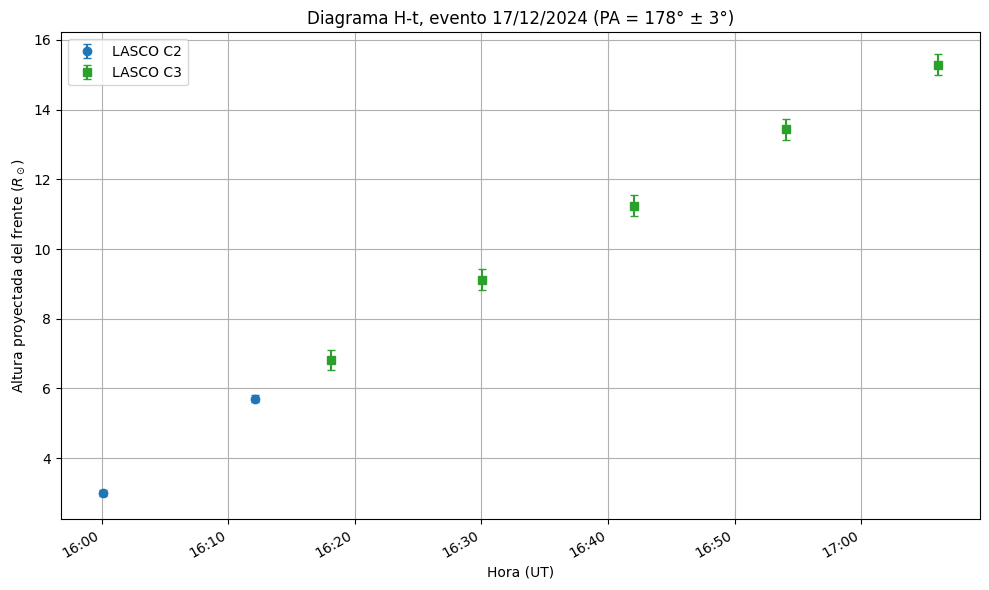

In [13]:
# --- Diagrama altura-tiempo con barras de error ---
fig, ax = plt.subplots(figsize=(10, 6))             # figura del diagrama h-t
estilo = {"C2": ("o", "tab:blue"), "C3": ("s", "tab:green")}   # marcador y color por detector
for nombre in DETECTORES:                           # dibuja cada detector por separado
    filas = [f for f in tabla if f["detector"] == nombre]      # mediciones de este detector
    if not filas:                                   # si no hubo ninguna, se omite
        continue
    t = [np.datetime64(f["tiempo_utc"]).astype("datetime64[s]").astype(object) for f in filas]  # horas como datetime
    h = [f["altura_rsun"] for f in filas]           # alturas (R_sun)
    s = [f["sigma_rsun"] for f in filas]            # incertidumbres (R_sun)
    ax.errorbar(t, h, yerr=s, fmt=estilo[nombre][0], color=estilo[nombre][1],
                capsize=3, label=f"LASCO {nombre}")  # puntos con barras de error
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))    # eje x en formato HH:MM
ax.set_xlabel("Hora (UT)")                          # etiqueta del eje x
ax.set_ylabel(r"Altura proyectada del frente ($R_\odot$)")     # etiqueta del eje y (símbolo solar con mathtext)
ax.set_title(f"Diagrama H-t, evento 17/12/2024 (PA = {PA_CENTRO:.0f}° ± {PA_SEMIANCHO:.0f}°)")  # título
ax.grid(True)                                       # cuadrícula
ax.legend()                                         # leyenda
fig.autofmt_xdate()                                 # inclina las horas para que no se solapen
fig.tight_layout()                                  # acomoda márgenes
fig.savefig(CARPETA_SALIDA / "diagrama_ht_evento1.png", dpi=150)  # guarda la figura
plt.show()                                          # la muestra en pantalla

## 8. Revisión visual (control de calidad)

Muestra las imágenes de diferencia con el sector (amarillo) y el frente detectado (círculo rojo). **Revísalas antes de confiar en los números:** el círculo debe seguir el borde exterior brillante de la CME.
Si en algún cuadro el círculo cae en un lugar equivocado, ajusta `UMBRAL_SNR`, `NIVEL_BORDE` o `PA_CENTRO` en la celda de parámetros y vuelve a ejecutar desde la celda 5.

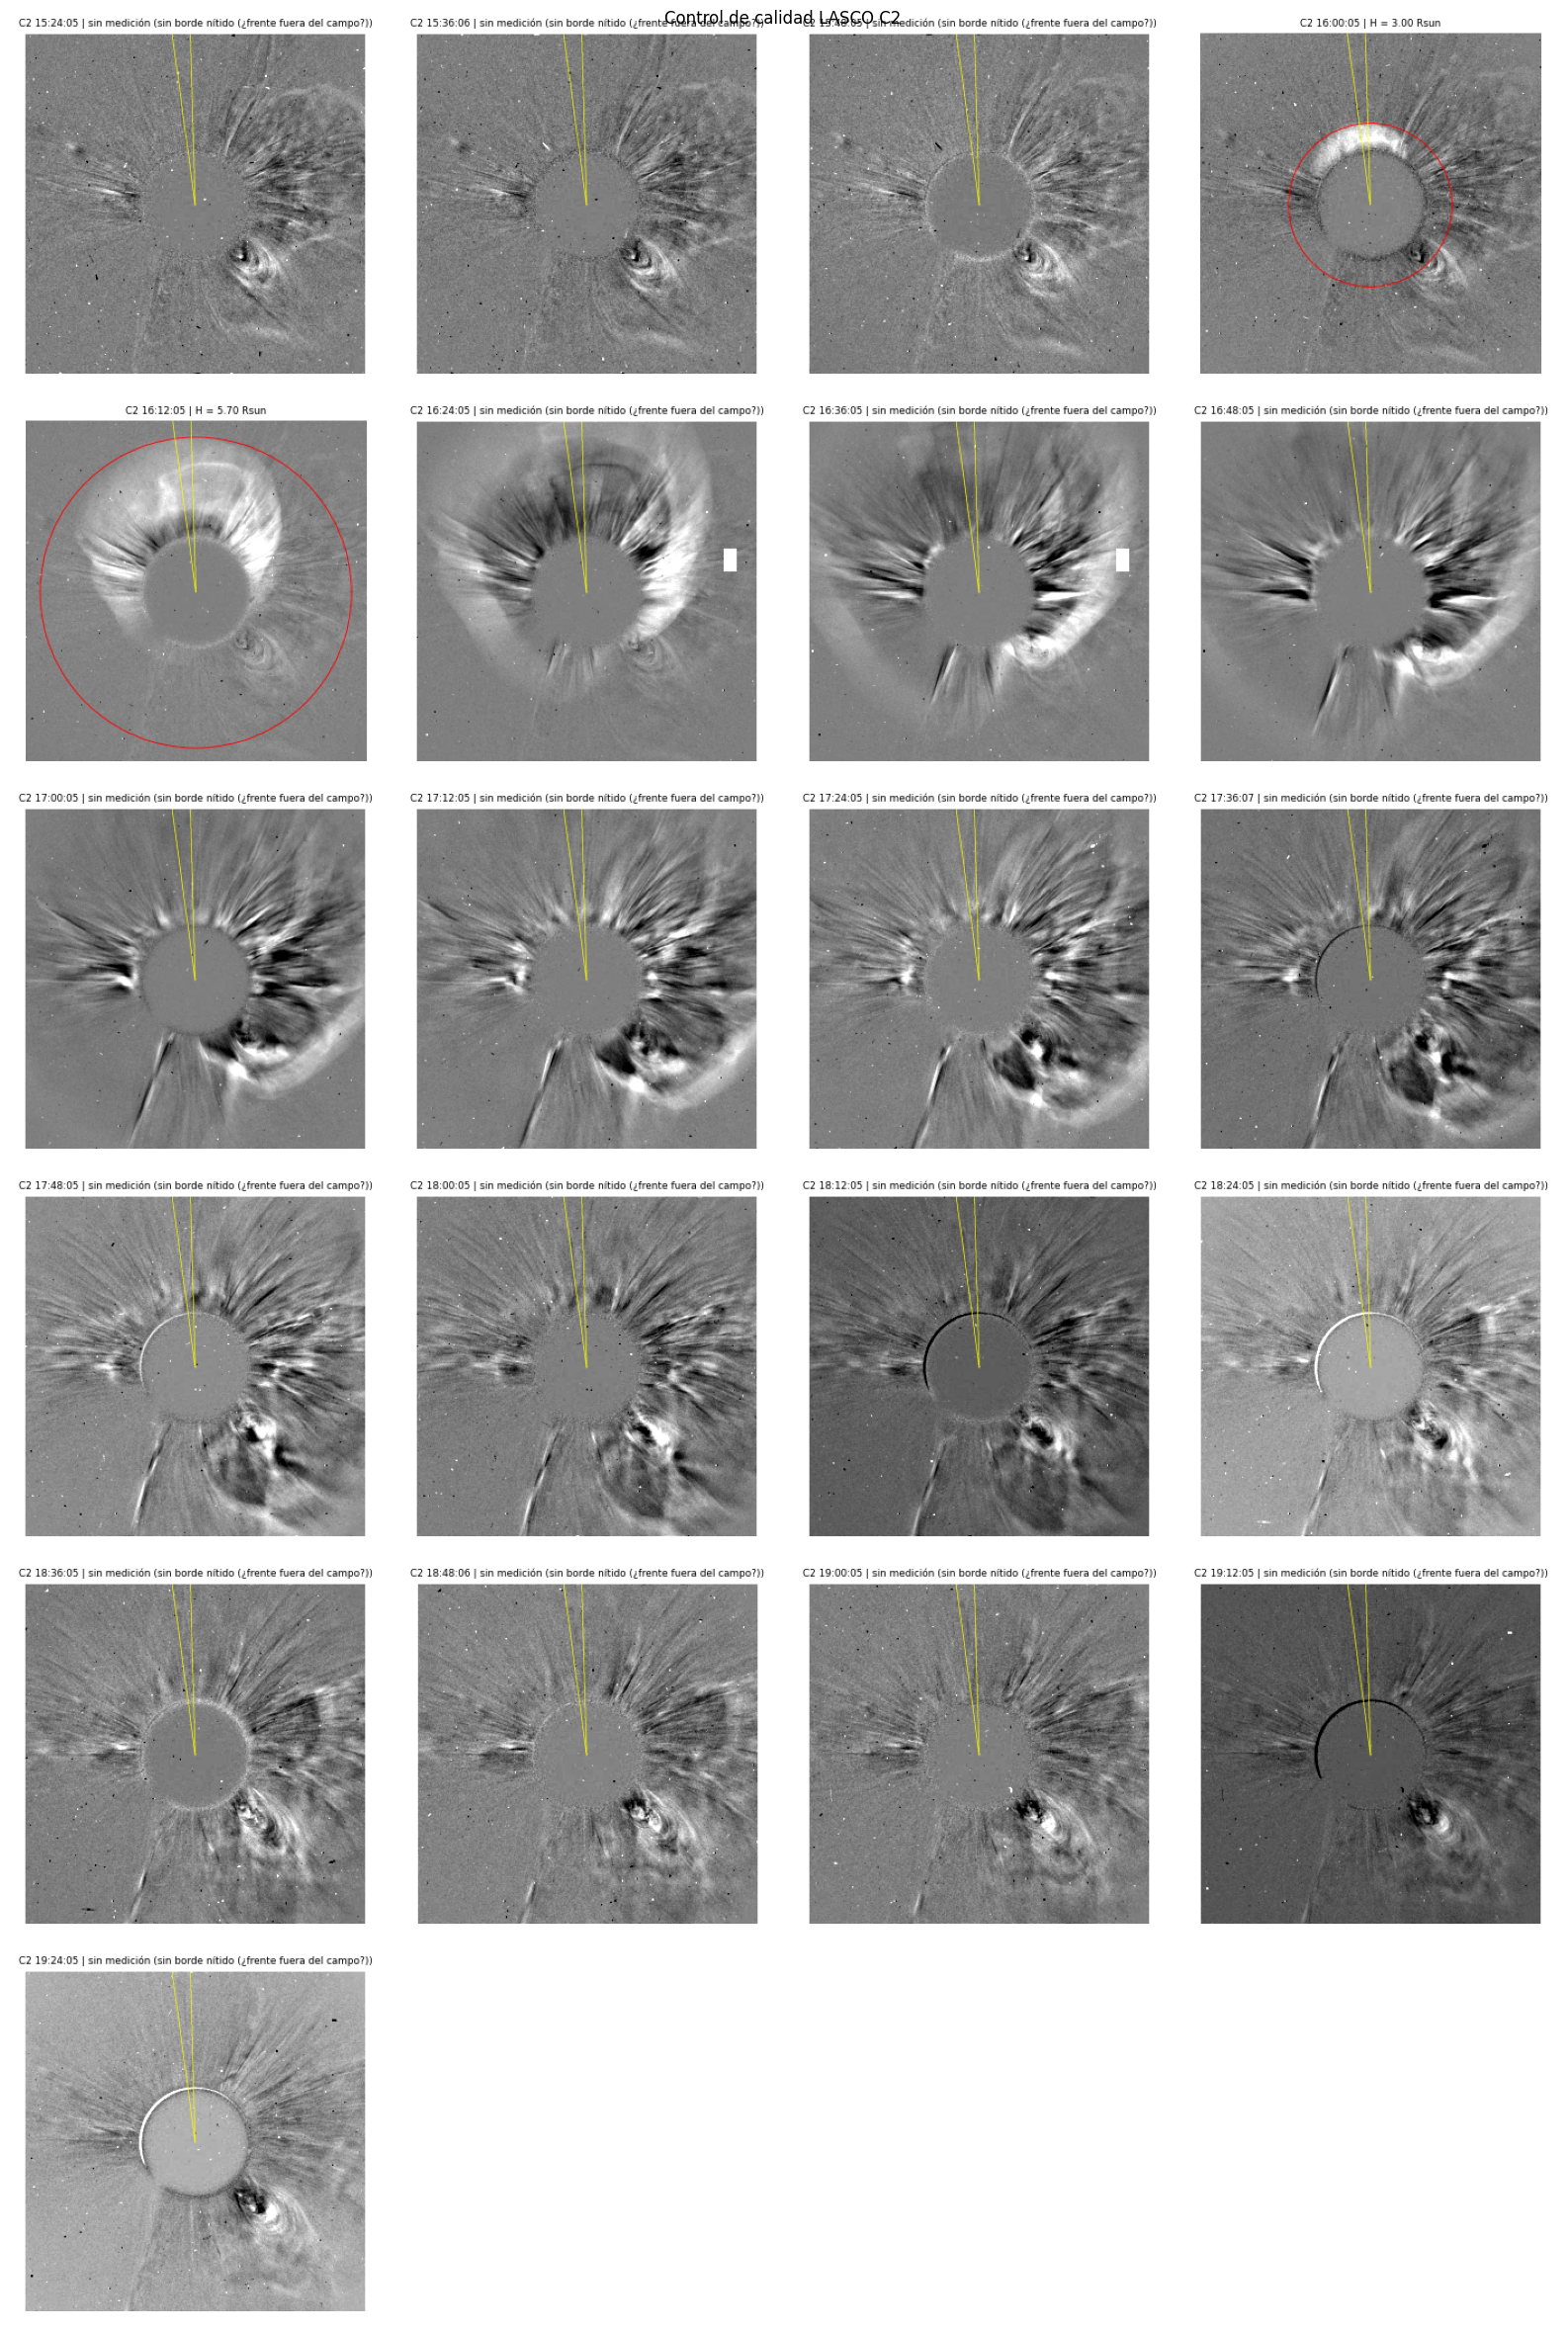

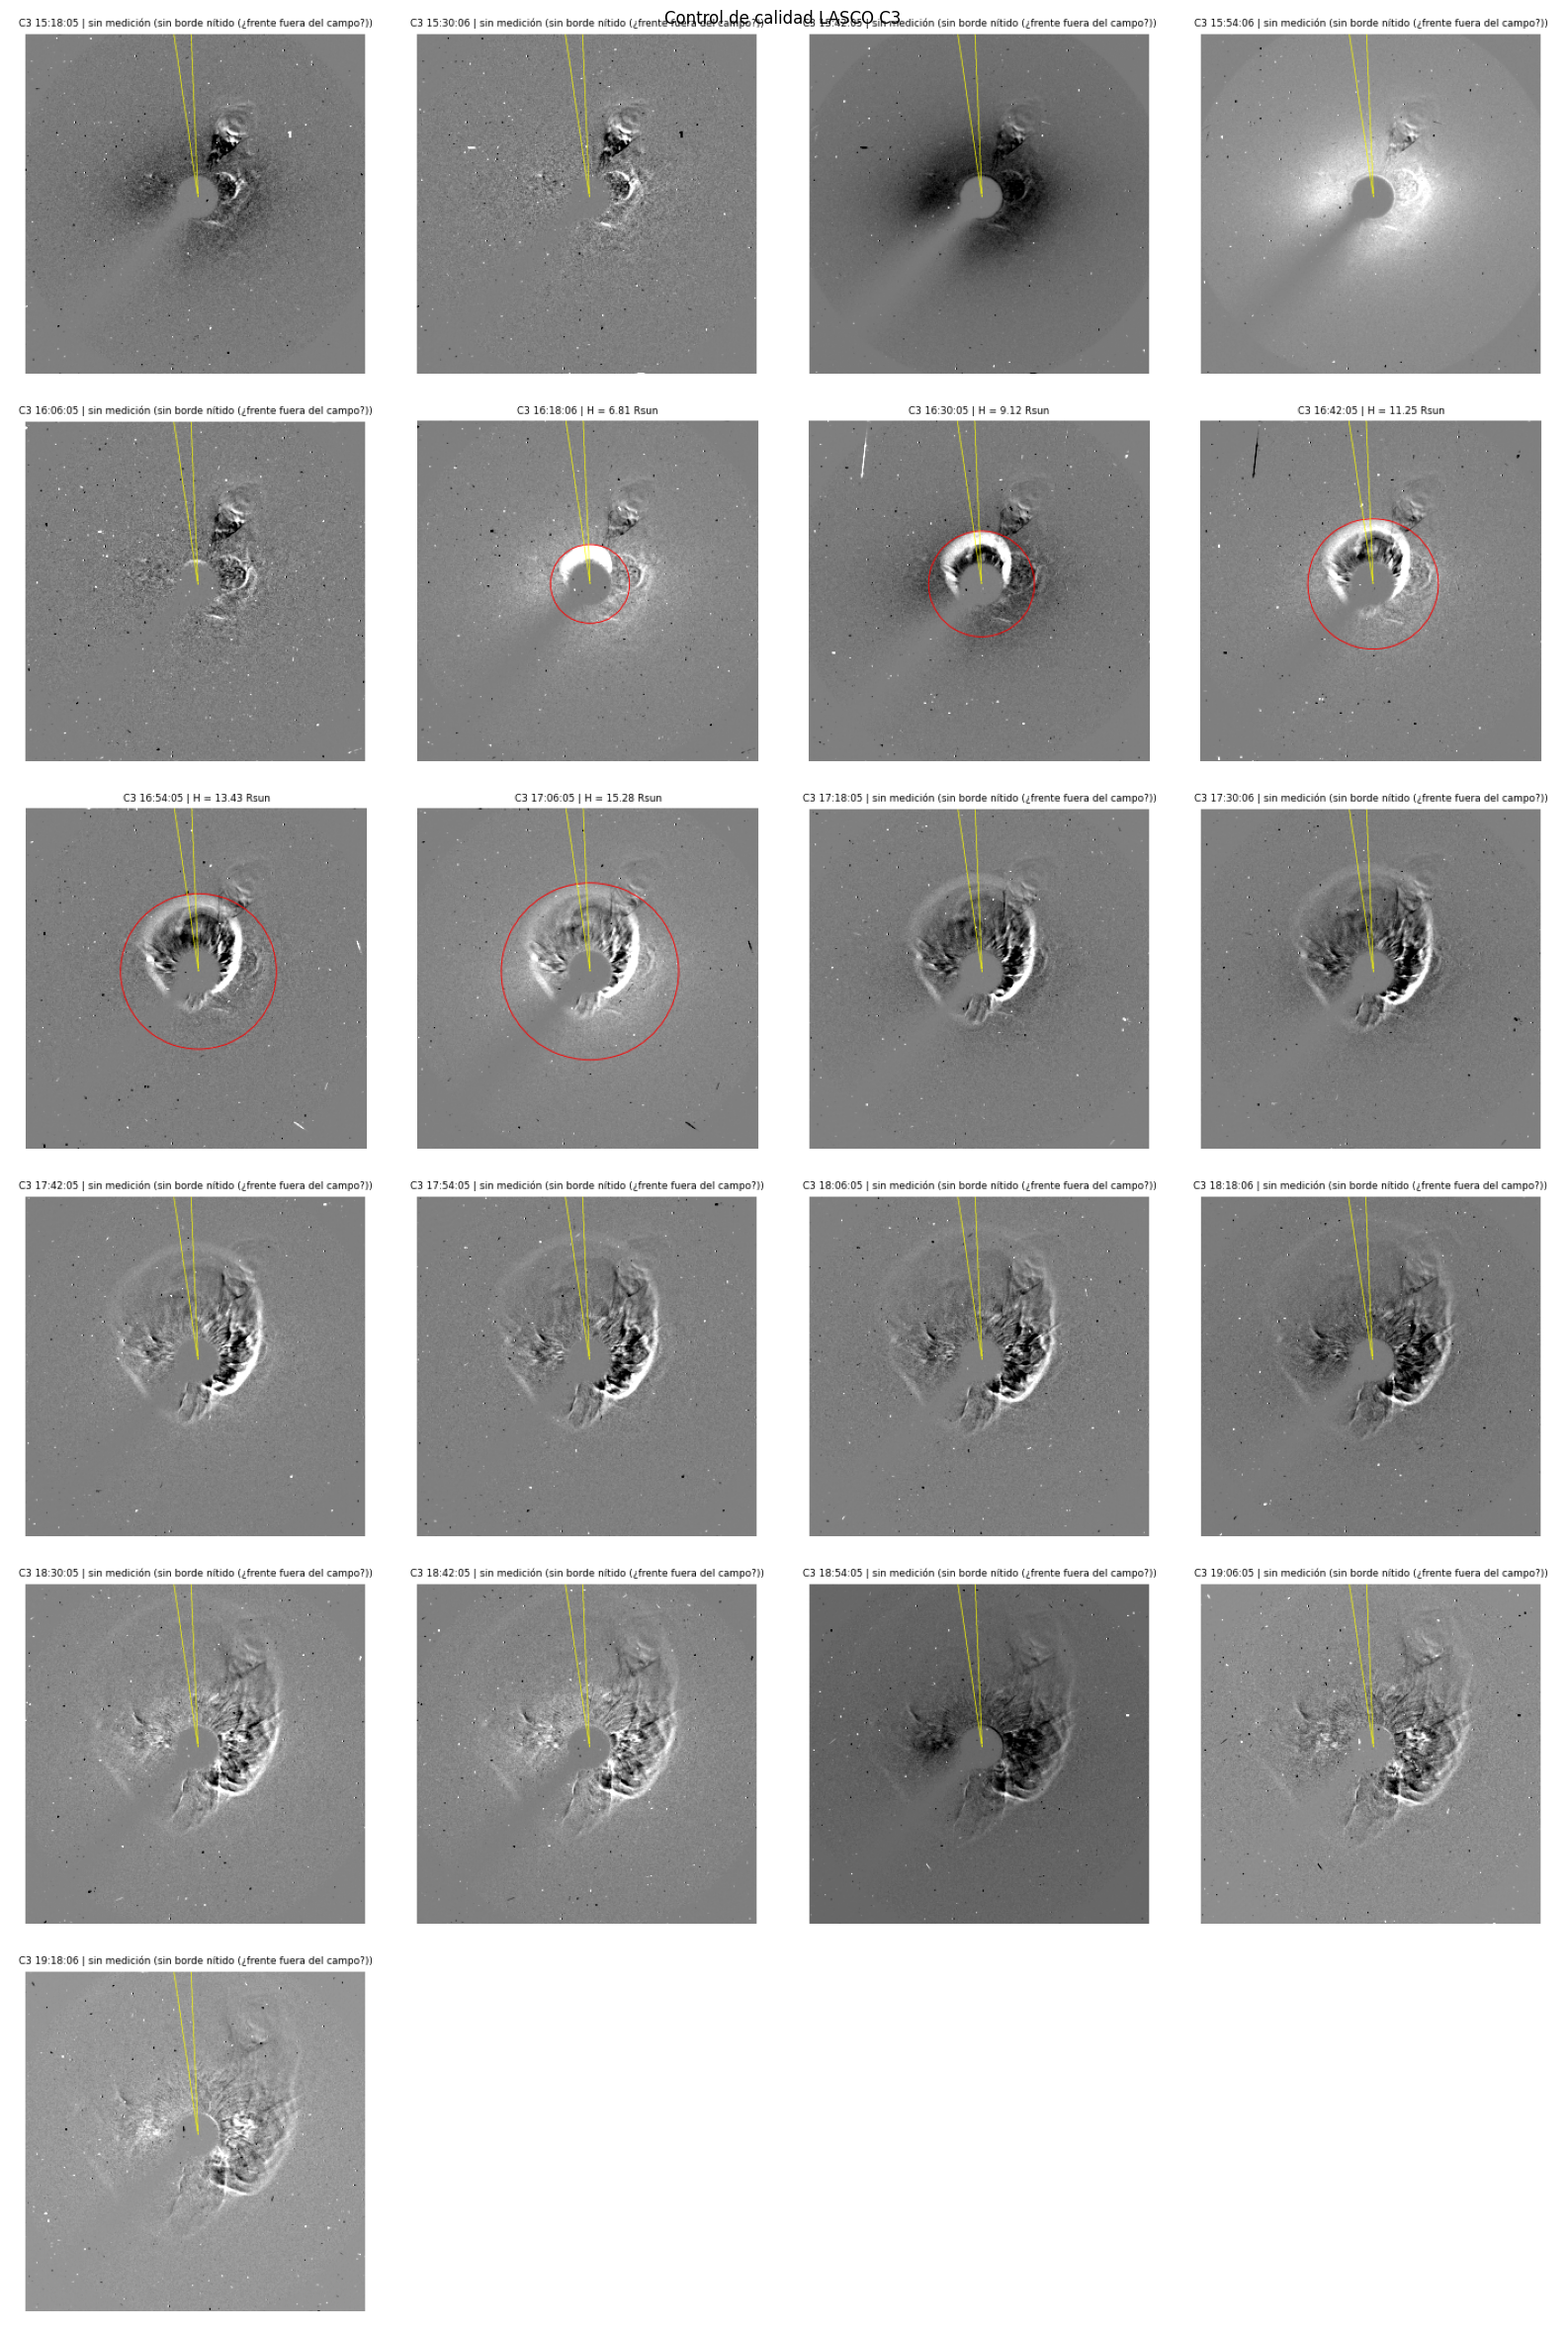

In [14]:
import matplotlib.image as mpimg                        # lectura de las imágenes PNG guardadas

for nombre in DETECTORES:                               # una cuadrícula por detector
    pngs = sorted((CARPETA_SALIDA / "control_calidad" / nombre).glob("*.png"))   # imágenes de control de este detector
    if not pngs:                                        # si no hay ninguna, se omite
        continue
    columnas = 4                                        # imágenes por fila
    filas_n = int(np.ceil(len(pngs) / columnas))        # filas necesarias
    fig, ejes = plt.subplots(filas_n, columnas, figsize=(4 * columnas, 4 * filas_n), squeeze=False)  # cuadrícula de ejes
    for eje in ejes.ravel():                            # se apagan todos los ejes (los sobrantes quedan vacíos)
        eje.axis("off")
    for eje, ruta in zip(ejes.ravel(), pngs):           # se dibuja cada imagen de control
        eje.imshow(mpimg.imread(ruta))
    fig.suptitle(f"Control de calidad LASCO {nombre}")  # título general
    fig.tight_layout()                                  # acomoda márgenes
    plt.show()                                          # muestra la cuadrícula en el cuaderno

## Siguiente paso

Con `ht_evento1.csv` completo (todas las imágenes del evento) se hace el ajuste lineal y cuadrático con incertidumbres (velocidad y aceleración) y el cálculo del volumen.